## Objectif

Ce notebook lance un entraînement SFT LoRA plus complet du modèle `Qwen/Qwen3-1.7B-Base` sur le dataset médical SFT.

Le run précédent `01_sft_lora_test_pipeline.ipynb` a validé la pipeline technique sur 1 époque.  
Ce notebook reprend la même pipeline corrigée et lance un entraînement sur 3 époques afin d'observer l'évolution des métriques et de produire un checkpoint SFT plus abouti.

Les objectifs sont :

- entraîner le modèle sur plusieurs époques ;
- suivre la train loss et la validation loss ;
- générer des checkpoints reproductibles ;
- surveiller le risque de sur-apprentissage ;
- préparer un checkpoint SFT pour l'évaluation et l'étape DPO.

In [7]:
import os
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
)
from peft import LoraConfig, get_peft_model

d:\Documents\Formation IA\Projet 14\projet14_311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
MODEL_NAME = "Qwen/Qwen3-1.7B-Base"

DATA_DIR = "../../data"
OUTPUT_DIR = "../../outputs/qwen3-sft-3epochs"

SEED = 42
MAX_LENGTH = 1024
NUM_EPOCHS = 3

## Vérification de l'environnement GPU

L'entraînement est réalisé sur GPU afin de réduire le temps de calcul.

Cette vérification permet de documenter l'environnement utilisé pour le run complet.

In [9]:
print("Torch :", torch.__version__)
print("CUDA disponible :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("Mémoire GPU totale :", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")

Torch : 2.5.1+cu121
CUDA disponible : True
GPU : NVIDIA GeForce RTX 4060 Laptop GPU
Mémoire GPU totale : 8.0 GB


## Chargement du tokenizer

Le tokenizer du modèle Qwen est chargé et configuré avec un token de padding.

Ce tokenizer sera utilisé pour convertir les exemples SFT en tokens.

In [10]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer chargé")
print("Pad token :", tokenizer.pad_token)
print("EOS token :", tokenizer.eos_token)

Tokenizer chargé
Pad token : <|endoftext|>
EOS token : <|endoftext|>


## Chargement du modèle de base

Le modèle `Qwen/Qwen3-1.7B-Base` est chargé en précision réduite sur GPU.

Contrairement au run de test initial, le modèle est placé explicitement sur `cuda:0` afin d'éviter les problèmes de paramètres sur device `meta` observés avec `device_map="auto"`.

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    trust_remote_code=True,
    low_cpu_mem_usage=False,
)

model.to(device)
model.config.use_cache = False
model.gradient_checkpointing_enable()

print("Modèle chargé")
print("Device principal :", next(model.parameters()).device)

Loading weights: 100%|██████████| 310/310 [00:03<00:00, 86.12it/s] 


Modèle chargé
Device principal : cuda:0


## Configuration LoRA

LoRA permet d'adapter le modèle sans réentraîner tous ses paramètres.

Le même paramétrage LoRA que le run de test est conservé, car la pipeline a été validée techniquement avec cette configuration.

In [12]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

meta_params = [
    name for name, param in model.named_parameters()
    if param.device.type == "meta"
]

print("Paramètres sur meta :", len(meta_params))
print("Devices utilisés :", sorted({str(param.device) for param in model.parameters()}))

trainable params: 1,605,632 || all params: 1,722,180,608 || trainable%: 0.0932
Paramètres sur meta : 0
Devices utilisés : ['cuda:0']


## Chargement des datasets SFT

Les jeux d'entraînement et de validation préparés à l'étape 1 sont chargés depuis le dossier `data`.

Le jeu `sft_test.jsonl` reste séparé et sera utilisé après l'entraînement pour l'évaluation finale du checkpoint SFT.

In [13]:
train_dataset = load_dataset(
    "json",
    data_files=f"{DATA_DIR}/sft_train.jsonl",
    split="train"
)

val_dataset = load_dataset(
    "json",
    data_files=f"{DATA_DIR}/sft_validation.jsonl",
    split="train"
)

print("Train :", len(train_dataset))
print("Validation :", len(val_dataset))
print(train_dataset[0])

Train : 4775
Validation : 618
{'instruction': 'Monsieur D., 77 ans, est hospitalisé à la demande de son médecin traitant pour\nconfusion aiguë.\nDans ses antécédents, figurent un infarctus du myocarde (qu’il a présenté il y a 10\nans), une artériopathie oblitérante des membres inférieurs, une hypertension\nartérielle et un diabète depuis 20 ans devenu insulino requérant depuis 10 ans.\nC’était un gros fumeur, sevré depuis une dizaine d’années.\nSon traitement habituel est le suivant :\n\nUMULINE® NPH (16 U le matin, 16 U le soir)\nACTOS® 15 (pioglitazone) : 1cp/j\nELISOR® 40 (pravastatine) : 1cp/j\nLASILIX® FAIBLE 20 mg (furosémide) : 1cp/j\nRENITEC® 20 (énalapril) : 1cp/j\nPLAVIX® 75 (clopidogrel) : 1cp/j\nNITRIDERM TTS® 5 mg (trinitrine) : 1/j\n\nA l’examen clinique d’entrée il est confus, très dyspnéique, encombré. Il présente de\ndiscrets oedèmes remontant jusqu’aux cuisses, sans reflux hépatojugulaire. La toux\nramène une expectoration mousseuse. Il pré

## Mise au format conversationnel

Chaque exemple SFT est converti en conversation Qwen.

Le prompt utilisateur et la réponse assistant sont séparés afin de pouvoir masquer le prompt dans les labels lors de la tokenisation.

In [14]:
def build_prompt(example):
    return (
        "<|im_start|>user\n"
        + example["instruction"].strip()
        + "\n<|im_end|>\n"
        + "<|im_start|>assistant\n"
    )

def build_full_text(example):
    return (
        build_prompt(example)
        + example["response"].strip()
        + "\n<|im_end|>"
    )

print(build_full_text(train_dataset[0]))

<|im_start|>user
Monsieur D., 77 ans, est hospitalisé à la demande de son médecin traitant pour
confusion aiguë.
Dans ses antécédents, figurent un infarctus du myocarde (qu’il a présenté il y a 10
ans), une artériopathie oblitérante des membres inférieurs, une hypertension
artérielle et un diabète depuis 20 ans devenu insulino requérant depuis 10 ans.
C’était un gros fumeur, sevré depuis une dizaine d’années.
Son traitement habituel est le suivant :

UMULINE® NPH (16 U le matin, 16 U le soir)
ACTOS® 15 (pioglitazone) : 1cp/j
ELISOR® 40 (pravastatine) : 1cp/j
LASILIX® FAIBLE 20 mg (furosémide) : 1cp/j
RENITEC® 20 (énalapril) : 1cp/j
PLAVIX® 75 (clopidogrel) : 1cp/j
NITRIDERM TTS® 5 mg (trinitrine) : 1/j

A l’examen clinique d’entrée il est confus, très dyspnéique, encombré. Il présente de
discrets oedèmes remontant jusqu’aux cuisses, sans reflux hépatojugulaire. La toux
ramène une expectoration mousseuse. Il présente une fièvre à 38°2.
Les examens biologiqu

## Tokenisation et masquage du prompt

Les exemples sont tokenisés au format causal language modeling.

Les tokens correspondant au prompt utilisateur sont masqués dans les labels avec la valeur `-100`.  
Ainsi, la loss est calculée uniquement sur la réponse assistant attendue.

In [15]:
def tokenize_function(example):
    prompt_text = build_prompt(example)
    full_text = build_full_text(example)

    tokenized_full = tokenizer(
        full_text,
        truncation=True,
        max_length=MAX_LENGTH,
        add_special_tokens=False,
    )

    tokenized_prompt = tokenizer(
        prompt_text,
        truncation=True,
        max_length=MAX_LENGTH,
        add_special_tokens=False,
    )

    input_ids = tokenized_full["input_ids"]
    attention_mask = tokenized_full["attention_mask"]

    labels = input_ids.copy()

    prompt_length = len(tokenized_prompt["input_ids"])
    prompt_length = min(prompt_length, len(labels))

    labels[:prompt_length] = [-100] * prompt_length

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }

## Application de la tokenisation

La tokenisation est appliquée aux jeux d'entraînement et de validation.

Les colonnes textuelles initiales sont supprimées pour conserver uniquement les champs nécessaires au `Trainer`.

In [16]:
tokenized_train = train_dataset.map(
    tokenize_function,
    remove_columns=train_dataset.column_names
)

tokenized_val = val_dataset.map(
    tokenize_function,
    remove_columns=val_dataset.column_names
)

print(tokenized_train)
print(tokenized_val)

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 4775
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 618
})


## Filtrage des exemples sans labels entraînables

Certains exemples longs peuvent être tronqués avant que la réponse assistant ne soit incluse.

Dans ce cas, tous les labels valent `-100`, ce qui empêche le calcul correct de la loss.  
Ces exemples sont retirés avant l'entraînement.

In [17]:
def has_trainable_labels(example):
    return any(label != -100 for label in example["labels"])

print("Avant filtrage train :", len(tokenized_train))
print("Avant filtrage validation :", len(tokenized_val))

tokenized_train = tokenized_train.filter(has_trainable_labels)
tokenized_val = tokenized_val.filter(has_trainable_labels)

print("Après filtrage train :", len(tokenized_train))
print("Après filtrage validation :", len(tokenized_val))

Avant filtrage train : 4775
Avant filtrage validation : 618
Après filtrage train : 4762
Après filtrage validation : 617


## Vérification des longueurs tokenisées

La distribution des longueurs permet de vérifier que `MAX_LENGTH=1024` reste adapté au run complet.

In [18]:
import numpy as np

train_lengths = np.array([len(example["input_ids"]) for example in tokenized_train])

print("Nombre d'exemples :", len(train_lengths))
print("Longueur moyenne :", round(train_lengths.mean(), 2))
print("Longueur médiane :", np.median(train_lengths))
print("Longueur max :", train_lengths.max())
print("> 512 tokens :", (train_lengths > 512).sum(), f"({(train_lengths > 512).mean() * 100:.2f}%)")
print("> 768 tokens :", (train_lengths > 768).sum(), f"({(train_lengths > 768).mean() * 100:.2f}%)")
print("= 1024 tokens :", (train_lengths == MAX_LENGTH).sum(), f"({(train_lengths == MAX_LENGTH).mean() * 100:.2f}%)")

Nombre d'exemples : 4762
Longueur moyenne : 329.06
Longueur médiane : 296.0
Longueur max : 1024
> 512 tokens : 1011 (21.23%)
> 768 tokens : 202 (4.24%)
= 1024 tokens : 26 (0.55%)


## Data collator

Le data collator prépare les batchs pour l'entraînement.

Il applique un padding dynamique afin de limiter la mémoire GPU utilisée.

In [19]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True
)

print("Data collator prêt")

Data collator prêt


## Configuration de l'entraînement complet

Ce run entraîne le modèle pendant 3 époques.

Les checkpoints et évaluations sont espacés afin de limiter le temps d'entraînement tout en conservant une traçabilité suffisante.

In [20]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    num_train_epochs=NUM_EPOCHS,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=2,

    learning_rate=2e-4,
    weight_decay=0.0,
    warmup_ratio=0.03,
    lr_scheduler_type="linear",

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,

    logging_steps=50,

    fp16=torch.cuda.is_available(),

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    report_to="none",

    seed=SEED,
    data_seed=SEED,

    remove_unused_columns=False,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## Création du Trainer

Le `Trainer` est initialisé avec le modèle LoRA, les datasets tokenisés, les hyperparamètres et le data collator.

In [21]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
)

print("Trainer créé")
print("Nombre d'exemples train :", len(tokenized_train))
print("Nombre d'exemples validation :", len(tokenized_val))
print("Dossier de sortie :", OUTPUT_DIR)

Trainer créé
Nombre d'exemples train : 4762
Nombre d'exemples validation : 617
Dossier de sortie : ../../outputs/qwen3-sft-3epochs


## Lancement de l'entraînement SFT LoRA complet

L'entraînement est lancé pour 3 époques.

Les métriques et checkpoints seront enregistrés dans le dossier de sortie configuré.

In [16]:
train_result = trainer.train()

train_result

Epoch,Training Loss,Validation Loss
1,2.162260,2.248884
2,1.909145,2.204758
3,1.671062,2.202288


TrainOutput(global_step=7143, training_loss=1.9909887259102963, metrics={'train_runtime': 6585.3307, 'train_samples_per_second': 2.169, 'train_steps_per_second': 1.085, 'total_flos': 3.97982193302016e+16, 'train_loss': 1.9909887259102963, 'epoch': 3.0})

## Résultats du run SFT LoRA complet

| Epoch | Training loss | Validation loss |
|---:|---:|---:|
| 1 | 2.162260 | 2.248884 |
| 2 | 1.909145 | 2.204758 |
| 3 | 1.671062 | 2.202288 |

La train loss diminue nettement sur les 3 époques, ce qui indique que le modèle apprend les exemples du dataset SFT.

La validation loss diminue entre l'époque 1 et l'époque 2, puis se stabilise à l'époque 3.  
Cette évolution suggère que l'entraînement améliore la généralisation au début, mais que le gain devient marginal après la deuxième époque.

L'écart croissant entre train loss et validation loss à l'époque 3 indique un début possible de sur-apprentissage. Le checkpoint final reste toutefois exploitable pour l'évaluation intermédiaire, car la validation loss ne se dégrade pas.

In [22]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("Checkpoint SFT 3 epochs sauvegardé dans :", OUTPUT_DIR)

Checkpoint SFT 3 epochs sauvegardé dans : ../../outputs/qwen3-sft-3epochs


## Suivi des métriques d'entraînement

Les logs du `Trainer` sont récupérés depuis le checkpoint final afin de visualiser l'évolution de la train loss et de la validation loss pendant le run complet.

In [1]:
import json
import pandas as pd

trainer_state_path = "../../outputs/qwen3-sft-3epochs/checkpoint-7143/trainer_state.json"

with open(trainer_state_path, "r", encoding="utf-8") as f:
    trainer_state = json.load(f)

logs_df = pd.DataFrame(trainer_state["log_history"])

logs_df.tail()

,epoch,grad_norm,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
140,2.918942,2.117901,0.000006,1.900881,6950,NaN,NaN,NaN,NaN
141,2.939941,2.231083,0.000004,1.813363,7000,NaN,NaN,NaN,NaN
142,2.960941,3.154343,0.000003,1.892491,7050,NaN,NaN,NaN,NaN
143,2.981940,7.510061,0.000001,1.671062,7100,NaN,NaN,NaN,NaN
144,3.000000,NaN,NaN,NaN,7143,2.202288,63.6588,9.692,9.692


## Visualisation de la loss

Le graphique ci-dessous permet de suivre la convergence du modèle pendant les 3 époques d'entraînement.

La courbe de validation est utilisée pour surveiller le risque de sur-apprentissage.

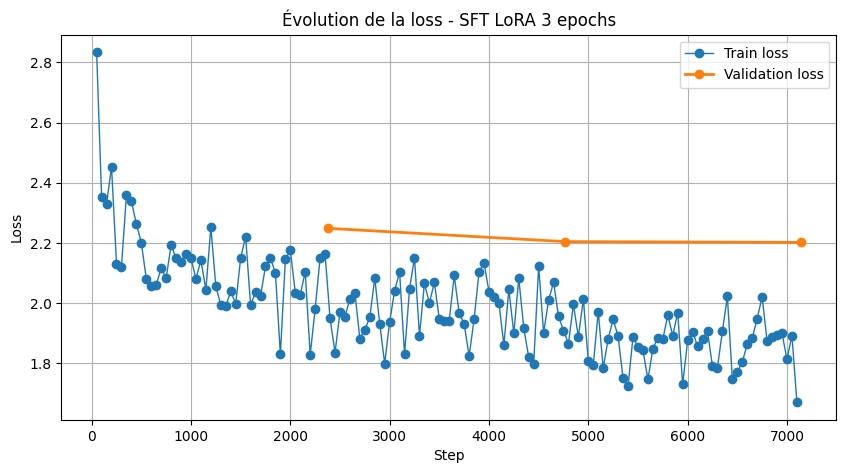

In [2]:
import matplotlib.pyplot as plt

train_logs = logs_df[logs_df["loss"].notna()]
eval_logs = logs_df[logs_df["eval_loss"].notna()]

plt.figure(figsize=(10, 5))

plt.plot(
    train_logs["step"],
    train_logs["loss"],
    label="Train loss",
    marker="o",
    linewidth=1
)

plt.plot(
    eval_logs["step"],
    eval_logs["eval_loss"],
    label="Validation loss",
    marker="o",
    linewidth=2
)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Évolution de la loss - SFT LoRA 3 epochs")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
logs_path = "../../outputs/qwen3-sft-3epochs/training_logs.csv"
logs_df.to_csv(logs_path, index=False)

print("Logs sauvegardés :", logs_path)

Logs sauvegardés : ../../outputs/qwen3-sft-3epochs/training_logs.csv


## Interprétation des résultats

Le run SFT LoRA complet s'est terminé correctement sur 3 époques.

| Epoch | Training loss | Validation loss |
|---:|---:|---:|
| 1 | 2.162260 | 2.248884 |
| 2 | 1.909145 | 2.204758 |
| 3 | 1.671062 | 2.202288 |

La train loss diminue nettement au fil des époques, ce qui indique que le modèle apprend les exemples du dataset SFT.

La validation loss diminue entre l'époque 1 et l'époque 2, puis se stabilise à l'époque 3.  
Le gain de validation après la deuxième époque devient donc marginal.

L'écart croissant entre la train loss et la validation loss peut indiquer un début de sur-apprentissage. Cependant, la validation loss ne se dégrade pas à l'époque 3, ce qui permet de conserver le checkpoint final comme checkpoint SFT exploitable pour l'évaluation intermédiaire.

Ce run valide l'entraînement SFT LoRA demandé dans l'étape 2 :
- entraînement du modèle `Qwen/Qwen3-1.7B-Base` ;
- adaptation avec LoRA pour limiter l'empreinte GPU ;
- checkpoints reproductibles ;
- suivi des métriques d'entraînement et de validation ;
- sauvegarde des logs pour la traçabilité.

In [6]:
import os

print("Dossier final :", OUTPUT_DIR)
print(os.listdir(OUTPUT_DIR))

Dossier final : ../../outputs/qwen3-sft-3epochs
['adapter_config.json', 'adapter_model.safetensors', 'chat_template.jinja', 'checkpoint-2381', 'checkpoint-4762', 'checkpoint-7143', 'README.md', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin', 'training_logs.csv']


Le suivi expérimental a été réalisé à partir des logs Hugging Face Trainer, sauvegardés en CSV et visualisés sous forme de graphiques dans les notebooks. MLflow/W&B n'ont pas été utilisés afin de conserver une pipeline locale simple et reproductible pour ce POC académique.

| Run | Output dir | Epochs | Seed | LR | LoRA r/alpha | Checkpoints | Logs |
|---|---|---:|---:|---:|---|---|---|
| SFT test pipeline | `outputs/qwen3-sft-run-test` | 1 | 42 | 2e-4 | r=8, alpha=16 | oui | `training_logs.csv` |
| SFT full run | `outputs/qwen3-sft-3epochs` | 3 | 42 | 2e-4 | r=8, alpha=16 | oui | `training_logs.csv` |